# Chapter 1: Exploratory Data Analysis

## Summary

Exploratory Data Analysis (EDA) is the foundation of every data science project. Before building predictive models or applying machine learning algorithms, it is essential to understand the structure, quality, and characteristics of the data.

This chapter introduces the basic concepts of exploratory data analysis, including structured data, rectangular data, measures of location, measures of variability, data distributions, correlation analysis, and visualization techniques. These concepts help data scientists identify patterns, detect anomalies, understand relationships between variables, and prepare data for further analysis.

EDA provides valuable insights into datasets and supports informed decision-making throughout the data science workflow.

## Learning Objectives

After completing this chapter, students should be able to:

- Understand different types of structured data.
- Distinguish between numeric and categorical variables.
- Explain rectangular data structures used in data science.
- Calculate measures of location such as mean and median.
- Calculate measures of variability such as standard deviation and interquartile range.
- Analyze data distributions using statistical summaries.
- Interpret correlations between variables.
- Apply visualization techniques for exploratory data analysis.
- Understand the importance of EDA before machine learning modeling.

## Theory: Elements of Structured Data

Data used in data science can generally be classified into structured and unstructured data. Structured data is organized into rows and columns, making it suitable for statistical analysis and machine learning.

The main types of structured data include:

### Numeric Data

Numeric data represents measurable quantities.

#### Continuous Data
Continuous data can take any value within a range.

Examples:
- Temperature
- Height
- Weight
- Time

#### Discrete Data
Discrete data consists of countable values.

Examples:
- Number of students
- Number of transactions
- Number of website visitors

### Categorical Data

Categorical data represents categories or groups.

Examples:
- Gender
- Country
- Product category

### Binary Data

Binary data is a special form of categorical data containing only two possible values.

Examples:
- Yes / No
- True / False
- Fraud / Non-Fraud

### Ordinal Data

Ordinal data contains categories with a meaningful order.

Examples:
- Education level
- Customer satisfaction ratings
- Product rankings

## Theory: Rectangular Data

Rectangular data is the most common data structure used in statistics, machine learning, and data science.

A rectangular dataset consists of:

- Rows → Records or observations
- Columns → Features or variables

Example:

| Age | Salary | Purchased |
|------|---------|-----------|
| 25 | 5000 | Yes |
| 30 | 7000 | No |
| 35 | 9000 | Yes |

Terminology commonly used in data science:

- Feature: Input variable used for analysis.
- Target/Outcome: Variable to be predicted.
- Record: Individual observation in the dataset.

Most machine learning algorithms require data in rectangular format before training can begin.

In [2]:
import pandas as pd
import numpy as np

data = {
    'Age': [25, 30, 35, 40, 45],
    'Salary': [5000, 7000, 9000, 11000, 13000]
}

df = pd.DataFrame(data)

df

,Age,Salary
0,25,5000
1,30,7000
2,35,9000
3,40,11000
4,45,13000


## Code Explanation

The code creates a simple rectangular dataset using Pandas DataFrame.

The dataset contains:

- Age as a feature.
- Salary as a feature.

Each row represents an observation, while each column represents a variable. This structure is the foundation of most machine learning datasets.

## Theory: Estimates of Location

Measures of location describe the central tendency of a dataset. They provide information about where the majority of data values are concentrated.

### Mean

The mean is the average value of a dataset and is calculated by summing all observations and dividing by the number of observations.

Mean = Sum of Values / Number of Values

### Median

The median is the middle value after sorting the data. It is more robust than the mean because it is less affected by outliers.

### Trimmed Mean

The trimmed mean is calculated by removing a certain percentage of extreme values from both ends of the distribution before computing the average.

This approach reduces the influence of outliers.

### Weighted Mean

A weighted mean assigns different importance (weights) to observations.

Weighted means are commonly used when observations have different levels of reliability or significance.

### Why Are These Important?

Measures of location help data scientists summarize large datasets using a single representative value. They are often the first statistics computed during exploratory data analysis.

In [3]:
import pandas as pd
from scipy.stats import trim_mean

population = pd.Series([
    4779736,
    710231,
    6392017,
    2915918,
    37253956,
    5029196,
    3574097,
    897934
])

print("Mean Population:")
print(population.mean())

print("\nMedian Population:")
print(population.median())

print("\nTrimmed Mean Population:")
print(trim_mean(population, 0.1))

Mean Population:
7694135.625

Median Population:
4176916.5

Trimmed Mean Population:
7694135.625


## Code Explanation

The code reproduces the concept of location estimates discussed in the chapter.

Three statistics are calculated:

1. Mean
2. Median
3. Trimmed Mean

The mean uses all observations and can be influenced by extreme values.

The median focuses on the center of the dataset and is more robust to outliers.

The trimmed mean removes a percentage of extreme values before computing the average, reducing the impact of unusually large or small observations.

These statistics help summarize the central tendency of a dataset.

In [4]:
import numpy as np

murder_rate = [5.7, 5.6, 4.7, 5.6, 4.4, 2.8, 2.4, 5.8]

weights = population

weighted_mean = np.average(
    murder_rate,
    weights=weights
)

print("Weighted Mean Murder Rate:")
print(weighted_mean)

Weighted Mean Murder Rate:
4.376359279149048


## Discussion

The results demonstrate that different measures of location can produce different values depending on the characteristics of the dataset.

The mean is sensitive to extreme observations, while the median remains relatively stable. This makes the median a preferred choice when outliers are present.

The trimmed mean provides a balance between the mean and median by reducing the influence of extreme values while still using most of the data.

The weighted mean is useful when observations contribute differently to the overall estimate. In this example, states with larger populations have greater influence on the final murder rate estimate.

## Theory: Estimates of Variability

Measures of variability describe how spread out the data values are around a central value. While measures of location indicate the center of a dataset, measures of variability indicate the degree of dispersion.

Understanding variability is important because datasets with the same mean can have very different distributions.

### Variance

Variance measures the average squared deviation from the mean.

A larger variance indicates greater dispersion.

### Standard Deviation

Standard deviation is the square root of variance.

It is one of the most widely used measures of variability because it is expressed in the same units as the original data.

### Interquartile Range (IQR)

The Interquartile Range (IQR) measures the spread of the middle 50% of observations.

IQR = Q3 − Q1

where:

- Q1 = 25th percentile
- Q3 = 75th percentile

IQR is resistant to outliers and provides a robust measure of variability.

### Median Absolute Deviation (MAD)

MAD measures the median distance between observations and the dataset median.

MAD is more robust than standard deviation when extreme values are present.

In [6]:
import pandas as pd

population = pd.Series([
    4779736,
    710231,
    6392017,
    2915918,
    37253956,
    5029196,
    3574097,
    897934
])

print("Variance:")
print(population.var())

print("\nStandard Deviation:")
print(population.std())

Variance:
146549069168147.7

Standard Deviation:
12105745.29585633


In [7]:
q1 = population.quantile(0.25)
q3 = population.quantile(0.75)

iqr = q3 - q1

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)

Q1: 2411422.0
Q3: 5369901.25
IQR: 2958479.25


In [8]:
median = population.median()

mad = (population - median).abs().median()

print("Median:")
print(median)

print("\nMAD:")
print(mad)

Median:
4176916.5

MAD:
1738049.5


## Code Explanation

The code calculates several measures of variability.

### Variance

The variance measures the average squared distance between observations and the mean.

### Standard Deviation

The standard deviation provides a more interpretable measure because it uses the same units as the original data.

### Interquartile Range (IQR)

The IQR focuses on the middle 50% of observations and is less affected by extreme values.

### Median Absolute Deviation (MAD)

MAD calculates the median distance from the dataset median and is considered a robust measure of variability.

These statistics help data scientists understand the spread and consistency of data.

## Discussion

The variability measures indicate how dispersed the population values are.

The standard deviation and variance are strongly influenced by extreme values. In this dataset, California's large population contributes significantly to the overall variability.

The IQR and MAD provide more robust estimates because they focus on the central portion of the distribution and reduce the influence of outliers.

When analyzing real-world datasets, it is recommended to examine multiple variability measures rather than relying on a single statistic.

### Key Takeaways

- Variance measures average squared deviations from the mean.
- Standard deviation is the most commonly used variability metric.
- IQR measures the spread of the middle 50% of observations.
- MAD is robust against outliers.
- Multiple variability metrics provide a more complete understanding of data dispersion.

## Theory: Exploring the Data Distribution

Measures of location and variability summarize data using a few numerical values. However, understanding the overall distribution of data provides deeper insights into its structure.

### Percentiles

Percentiles divide ordered data into 100 equal parts.

Common percentiles include:

- 25th percentile (Q1)
- 50th percentile (Median)
- 75th percentile (Q3)

Percentiles help identify the position of observations within a dataset.

### Boxplots

A boxplot visualizes the distribution of data using:

- Minimum value
- First quartile (Q1)
- Median
- Third quartile (Q3)
- Maximum value

Boxplots are useful for detecting outliers and understanding data spread.

### Histograms

Histograms group observations into intervals (bins) and display their frequencies.

Histograms help identify:

- Distribution shape
- Skewness
- Concentration of values
- Potential outliers

### Density Plots

Density plots provide a smooth estimate of the distribution and are often easier to interpret than histograms.

In [9]:
percentiles = population.quantile([
    0.05,
    0.25,
    0.50,
    0.75,
    0.95
])

print(percentiles)

0.05      775927.05
0.25     2411422.00
0.50     4176916.50
0.75     5369901.25
0.95    26452277.35
dtype: float64


## Code Explanation

The code calculates several percentiles of the population data.

These percentiles help summarize the distribution:

- 5th percentile
- 25th percentile (Q1)
- 50th percentile (Median)
- 75th percentile (Q3)
- 95th percentile

Percentiles are commonly used in exploratory data analysis because they are less sensitive to extreme values than the mean.

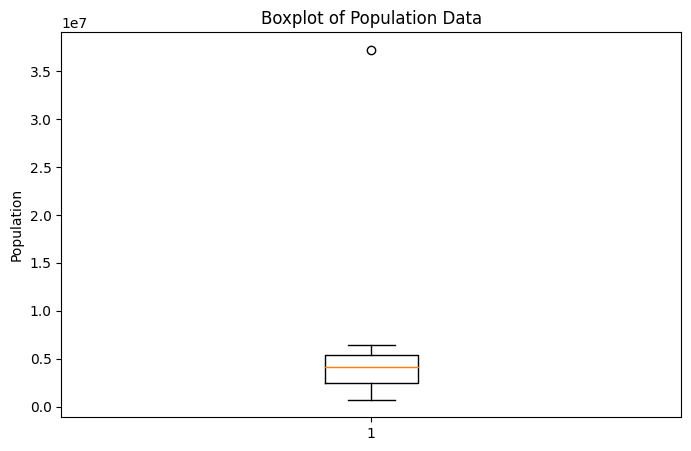

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(population)

plt.title("Boxplot of Population Data")
plt.ylabel("Population")

plt.show()

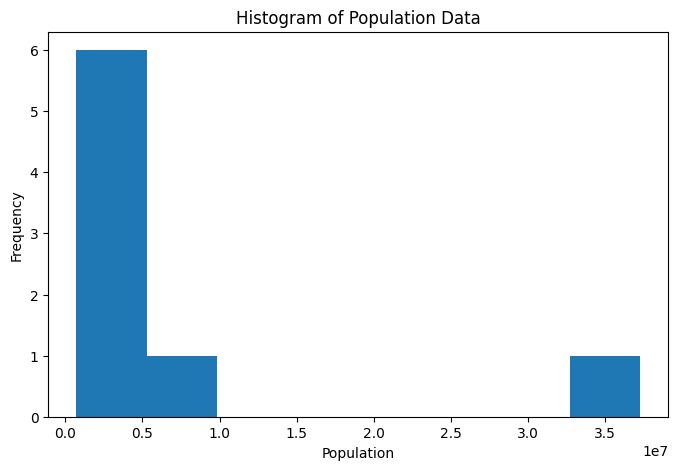

In [11]:
plt.figure(figsize=(8,5))

plt.hist(population, bins=8)

plt.title("Histogram of Population Data")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

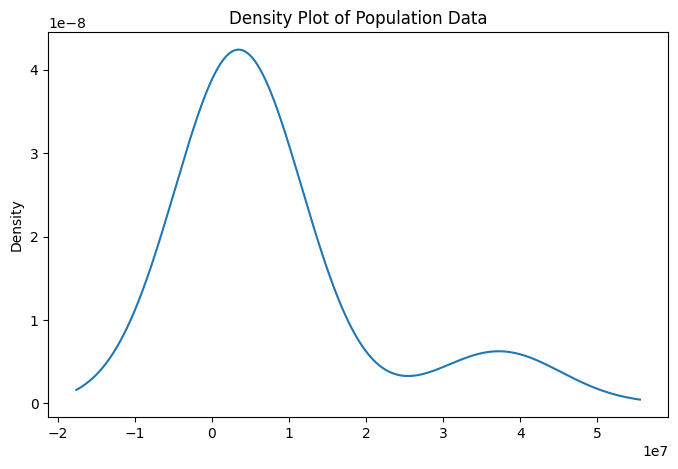

In [12]:
population.plot(
    kind='density',
    figsize=(8,5),
    title='Density Plot of Population Data'
)

plt.show()

## Discussion

The percentile analysis provides insight into how population values are distributed across observations.

The boxplot reveals the median, quartiles, and potential outliers. Large population values appear as extreme observations compared to the majority of states.

The histogram visualizes the frequency distribution and shows how observations are concentrated across different ranges.

The density plot provides a smooth representation of the distribution and highlights the overall shape of the data.

Together, these visualizations provide a more complete understanding of data distributions than summary statistics alone.

### Key Takeaways

- Percentiles summarize positions within a distribution.
- Boxplots help identify spread and outliers.
- Histograms reveal frequency distributions.
- Density plots provide smooth distribution estimates.
- Visualizations complement numerical statistics in exploratory data analysis.

## Theory: Exploring Binary and Categorical Data

Not all variables in a dataset are numerical. Many real-world datasets contain categorical and binary variables.

### Categorical Data

Categorical variables represent groups or categories.

Examples:

- Gender
- Country
- Product Category
- Education Level

### Binary Data

Binary variables contain only two possible outcomes.

Examples:

- Yes / No
- Fraud / Non-Fraud
- Pass / Fail

### Mode

The mode is the most frequently occurring value in a dataset.

For categorical variables, the mode is often used to identify the most common category.

### Probability

Probability measures the likelihood that an event will occur.

Probability values range from:

0 = Impossible Event

1 = Certain Event

Probability plays a critical role in statistical analysis and machine learning.

In [13]:
import pandas as pd

categories = pd.Series([
    'Electronics',
    'Clothing',
    'Electronics',
    'Food',
    'Electronics',
    'Clothing',
    'Food',
    'Electronics'
])

print("Frequency Count:")
print(categories.value_counts())

print("\nMode:")
print(categories.mode())

Frequency Count:
Electronics    4
Clothing       2
Food           2
Name: count, dtype: int64

Mode:
0    Electronics
dtype: object


## Code Explanation

The code demonstrates categorical data analysis.

The value_counts() function calculates the frequency of each category.

The mode() function identifies the category that appears most frequently.

This type of analysis is useful for understanding customer behavior, product popularity, and class distributions in machine learning datasets.

## Theory: Correlation Analysis

Correlation measures the strength and direction of the relationship between two numerical variables.

### Positive Correlation

When one variable increases and the other variable also increases.

### Negative Correlation

When one variable increases while the other decreases.

### No Correlation

When there is no consistent relationship between variables.

### Correlation Coefficient

The correlation coefficient ranges between:

-1 → Perfect Negative Correlation

0 → No Correlation

+1 → Perfect Positive Correlation

Correlation analysis is widely used during exploratory data analysis to identify relationships between variables.

In [14]:
import pandas as pd

df_corr = pd.DataFrame({
    'Age': [20, 25, 30, 35, 40, 45],
    'Salary': [3000, 4000, 5000, 7000, 9000, 11000]
})

correlation = df_corr['Age'].corr(df_corr['Salary'])

print("Correlation:")
print(correlation)

Correlation:
0.9885053652574968


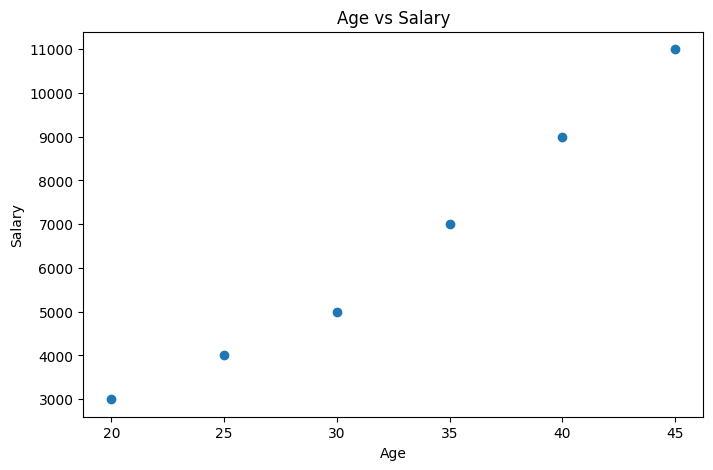

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_corr['Age'],
    df_corr['Salary']
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

## Code Explanation

The code calculates the Pearson correlation coefficient between Age and Salary.

A positive correlation indicates that salary tends to increase as age increases.

The scatterplot visually represents the relationship between the two variables.

Scatterplots are one of the most important visualization tools for identifying trends, clusters, and relationships in data.

## Discussion

Exploratory Data Analysis combines statistical summaries and visualizations to provide a comprehensive understanding of data.

Measures of location and variability help summarize datasets numerically, while visualizations reveal patterns, trends, and anomalies that may not be obvious from summary statistics alone.

Correlation analysis helps identify relationships between variables and supports feature selection for machine learning models.

By performing EDA before model development, data scientists can improve data quality, detect issues early, and make more informed analytical decisions.

## Conclusion

Exploratory Data Analysis (EDA) is a fundamental step in every data science and machine learning project.

This chapter introduced structured data, rectangular data, measures of location, measures of variability, data distributions, categorical data analysis, and correlation analysis.

The combination of statistical techniques and visualization methods enables data scientists to better understand datasets, identify patterns, detect outliers, and prepare data for predictive modeling.

A strong understanding of EDA provides the foundation for more advanced topics such as statistical inference, regression, classification, and machine learning.